In [ ]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===== LOAD DATASET =====
file_path = "facebook_combined.txt"   # change if needed

# Read edge list
G = nx.read_edgelist(file_path, nodetype=int)

# ===== CLEAN GRAPH =====
# Remove self loops
G.remove_edges_from(nx.selfloop_edges(G))

# Keep largest connected component (important for graph metrics)
if not nx.is_connected(G):
    G = G.subgraph(max(nx.connected_components(G), key=len)).copy()

print("Graph Loaded Successfully")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Graph Loaded Successfully
Nodes: 4039
Edges: 88234


In [ ]:
# ===== BASIC METRICS =====
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)
avg_degree = sum(dict(G.degree()).values()) / num_nodes

print("\nGraph Statistics:")
print(f"Nodes: {num_nodes}")
print(f"Edges: {num_edges}")
print(f"Density: {density:.6f}")
print(f"Average Degree: {avg_degree:.2f}")


Graph Statistics:
Nodes: 4039
Edges: 88234
Density: 0.010820
Average Degree: 43.69


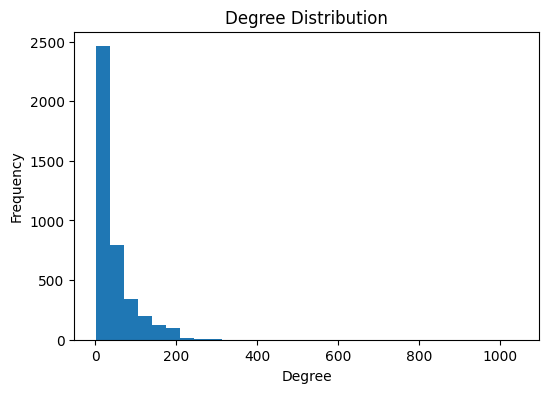

In [ ]:
degrees = [deg for node, deg in G.degree()]

plt.figure(figsize=(6,4))
plt.hist(degrees, bins=30)
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

In [ ]:
print("\nComputing centralities...")

# Degree
degree = nx.degree_centrality(G)

# Closeness
closeness = nx.closeness_centrality(G)

# PageRank (important)
pagerank = nx.pagerank(G)

# Betweenness (EXPENSIVE → sample-based for speed)
betweenness = nx.betweenness_centrality(G, k=100, seed=42)


Computing centralities...


In [ ]:
# Graph-based features
clustering = nx.clustering(G)
k_shell = nx.core_number(G)
avg_neighbor_degree = nx.average_neighbor_degree(G)

# Create DataFrame
df = pd.DataFrame({
    "node": list(G.nodes()),
    "degree": [degree[n] for n in G.nodes()],
    "betweenness": [betweenness[n] for n in G.nodes()],
    "closeness": [closeness[n] for n in G.nodes()],
    "pagerank": [pagerank[n] for n in G.nodes()],
    "clustering": [clustering[n] for n in G.nodes()],
    "k_shell": [k_shell[n] for n in G.nodes()],
    "avg_neighbor_degree": [avg_neighbor_degree[n] for n in G.nodes()]
})

df.head()

,node,degree,betweenness,closeness,pagerank,clustering,k_shell,avg_neighbor_degree
0,0,0.085934,1.573126e-01,0.353343,0.006290,0.041962,21,18.959654
1,1,0.004210,3.119848e-06,0.261376,0.000236,0.419118,13,48.235294
2,2,0.002476,3.096359e-07,0.261258,0.000203,0.888889,9,49.900000
3,3,0.004210,4.816558e-06,0.261376,0.000226,0.632353,13,59.764706
4,4,0.002476,0.000000e+00,0.261258,0.000238,0.866667,9,42.600000


In [ ]:
# Normalize features
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

saasp_features = df[[
    "degree",
    "avg_neighbor_degree",
    "clustering",
    "k_shell"
]]

scaled = scaler.fit_transform(saasp_features)

# SAASP-inspired score
df["saasp_score"] = (
    0.35 * scaled[:,0] +   # degree
    0.25 * scaled[:,1] +   # neighbor influence
    0.20 * scaled[:,2] +   # clustering
    0.20 * scaled[:,3]     # k-shell
)

df.head()

,node,degree,betweenness,closeness,pagerank,clustering,k_shell,avg_neighbor_degree,saasp_score
0,0,0.085934,1.573126e-01,0.353343,0.006290,0.041962,21,18.959654,0.162590
1,1,0.004210,3.119848e-06,0.261376,0.000236,0.419118,13,48.235294,0.120399
2,2,0.002476,3.096359e-07,0.261258,0.000203,0.888889,9,49.900000,0.205389
3,3,0.004210,4.816558e-06,0.261376,0.000226,0.632353,13,59.764706,0.165820
4,4,0.002476,0.000000e+00,0.261258,0.000238,0.866667,9,42.600000,0.199188


In [ ]:
# Use SAASP for labeling (NOT degree → correct ML practice)
threshold = df["saasp_score"].quantile(0.90)

df["influential"] = (df["saasp_score"] >= threshold).astype(int)

print(df["influential"].value_counts())

influential
0    3635
1     404
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Features (exclude leakage)
X = df[[
    "betweenness",
    "closeness",
    "pagerank",
    "clustering",
    "k_shell",
    "avg_neighbor_degree"
]]

y = df["influential"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("\nModel Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Model Performance:
Accuracy: 0.9888613861386139
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       740
           1       0.95      0.91      0.93        68

    accuracy                           0.99       808
   macro avg       0.97      0.95      0.96       808
weighted avg       0.99      0.99      0.99       808



In [ ]:
importances = model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("\nFeature Importance:")
print(feat_imp)


Feature Importance:
               feature  importance
4              k_shell    0.438318
5  avg_neighbor_degree    0.205482
2             pagerank    0.118037
3           clustering    0.108262
0          betweenness    0.066678
1            closeness    0.063223


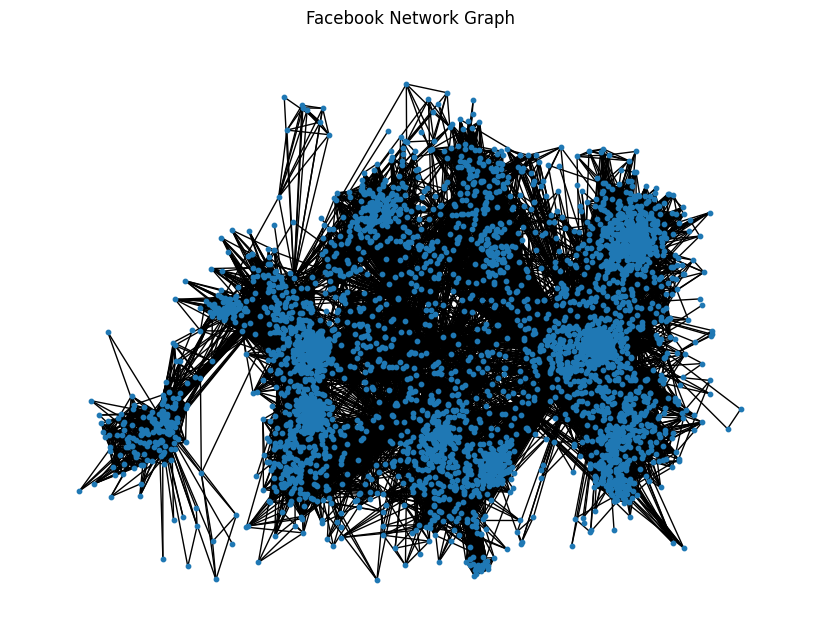

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Load dataset
G = nx.read_edgelist("facebook_combined.txt")

# Draw graph
plt.figure(figsize=(8,6))
nx.draw(G, node_size=10)
plt.title("Facebook Network Graph")
plt.show()

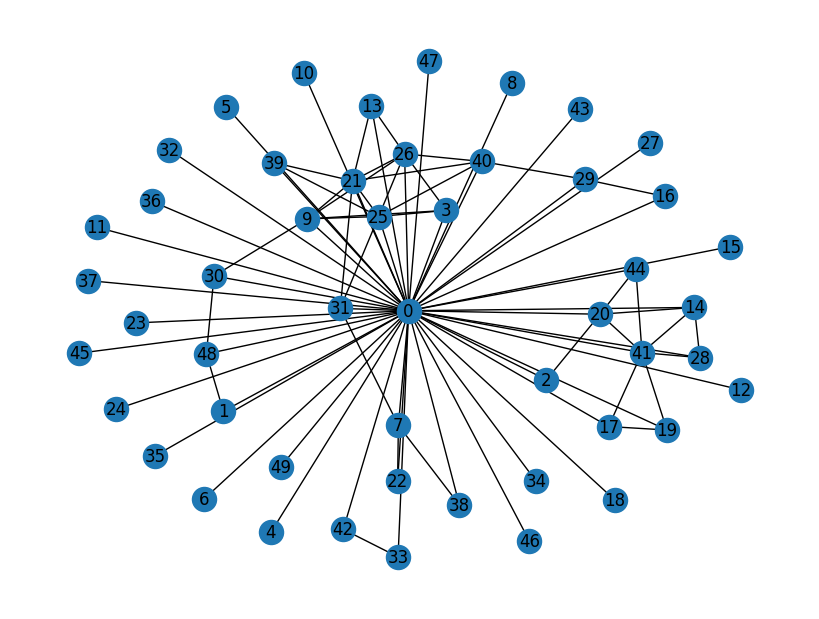

In [ ]:
# take a small subgraph
nodes = list(G.nodes())[:50]
subgraph = G.subgraph(nodes)

plt.figure(figsize=(8,6))
nx.draw(subgraph, with_labels=True, node_size=300)
plt.show()

In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1fmMjEGZO_th3Xoujqez8XKH3JVjSfrrggHoZj5euKEI/edit#gid=0


In [ ]:
# Calculate threshold (top 10%)
threshold = df["degree"].quantile(0.90)

# Create label column
df["influential"] = (df["degree"] >= threshold).astype(int)

df["influential"].value_counts()

,count
influential,
0,3635
1,404


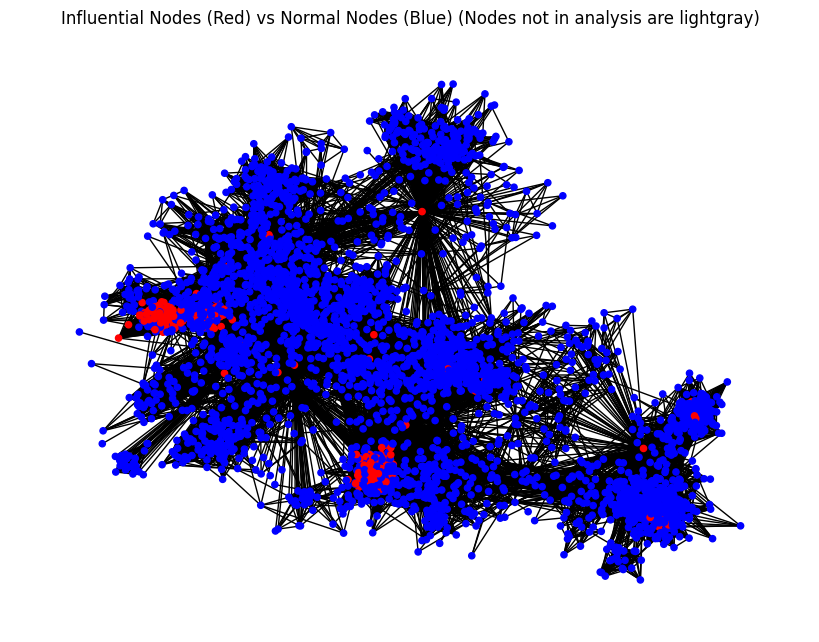

In [ ]:
plt.figure(figsize=(8,6))

color_map = []
node_ids_in_df = df["node"].unique()
for n_str in G.nodes():
    n_int = int(n_str) # Convert current graph node to int
    if n_int in node_ids_in_df:
        # Node is in df, get its influential status
        is_influential = df[df["node"] == n_int]["influential"].values[0]
        color_map.append("red" if is_influential == 1 else "blue")
    else:
        # Node is in G (raw graph) but not in df (cleaned graph), assign default color
        color_map.append("lightgray") # Assign a default color

nx.draw(G, node_color=color_map, node_size=20)

plt.title("Influential Nodes (Red) vs Normal Nodes (Blue) (Nodes not in analysis are lightgray)")
plt.show()

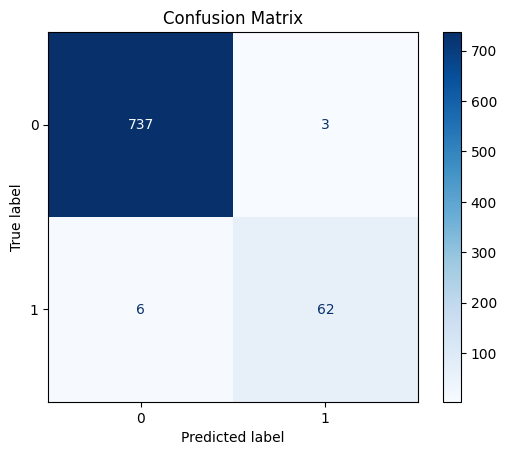

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

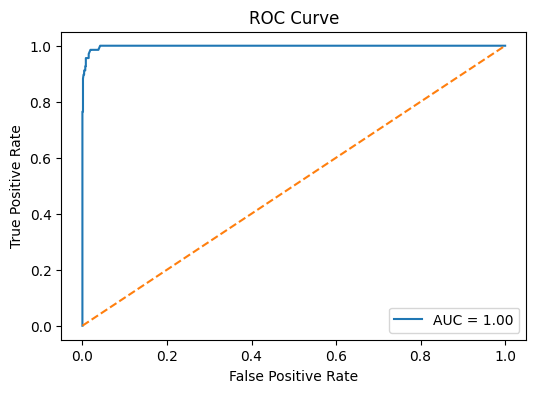

In [ ]:
from sklearn.metrics import roc_curve, auc

# Probabilities
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
from scipy.stats import spearmanr

# Sort rankings
saasp_rank = df.sort_values("saasp_score", ascending=False)["node"]
ml_rank = df.iloc[X_test.index].copy()
ml_rank["pred"] = y_pred

ml_rank = ml_rank.sort_values("pred", ascending=False)["node"]

# Align lists
common_nodes = list(set(saasp_rank).intersection(set(ml_rank)))

saasp_order = [list(saasp_rank).index(n) for n in common_nodes]
ml_order = [list(ml_rank).index(n) for n in common_nodes]

corr, _ = spearmanr(saasp_order, ml_order)

print("Spearman Correlation (SAASP vs ML):", corr)

Spearman Correlation (SAASP vs ML): 0.23079410334644376


In [ ]:
import random

def sir_simulation(G, initial_node, beta=0.3, gamma=0.1, steps=20):
    susceptible = set(G.nodes())
    infected = {initial_node}
    recovered = set()

    infected_count = []

    for _ in range(steps):
        new_infected = set()

        for node in infected:
            for neighbor in G.neighbors(node):
                if neighbor in susceptible and random.random() < beta:
                    new_infected.add(neighbor)

        new_recovered = set()
        for node in infected:
            if random.random() < gamma:
                new_recovered.add(node)

        infected = (infected | new_infected) - new_recovered
        susceptible -= new_infected
        recovered |= new_recovered

        infected_count.append(len(infected))

    return infected_count

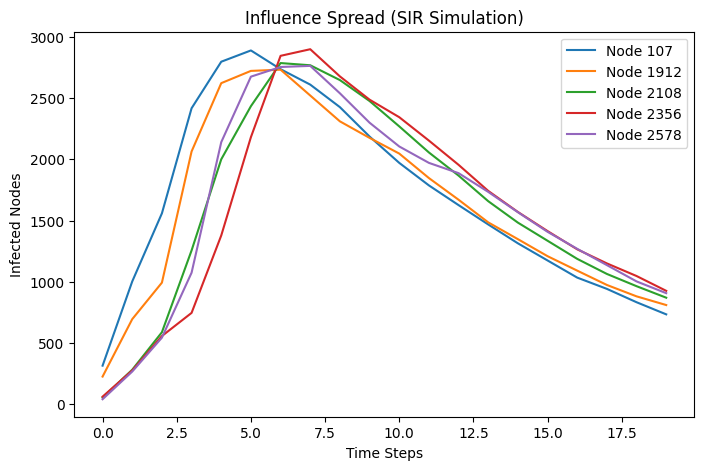

In [ ]:
# Pick top nodes
top_saasp_nodes = df.sort_values("saasp_score", ascending=False)["node"].head(5)

plt.figure(figsize=(8,5))

for node in top_saasp_nodes:
    spread = sir_simulation(G, str(node)) # Convert node to string to match graph's node type
    plt.plot(spread, label=f"Node {node}")

plt.xlabel("Time Steps")
plt.ylabel("Infected Nodes")
plt.title("Influence Spread (SIR Simulation)")
plt.legend()
plt.show()

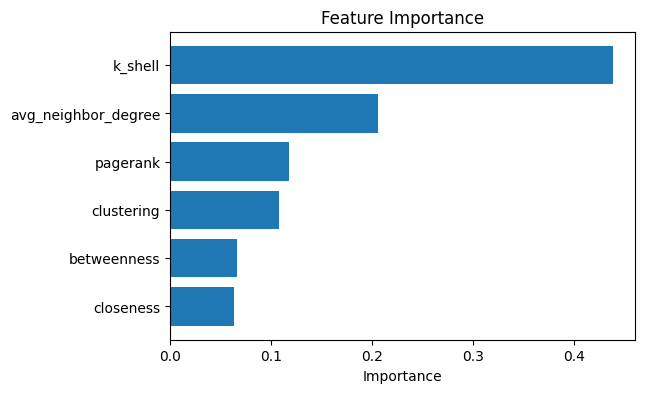

In [ ]:
import matplotlib.pyplot as plt

feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(6,4))
plt.barh(feat_imp["feature"], feat_imp["importance"])
plt.gca().invert_yaxis()

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

In [ ]:
model.feature_importances_

array([0.06667838, 0.0632233 , 0.11803652, 0.10826181, 0.43831768,
       0.20548231])

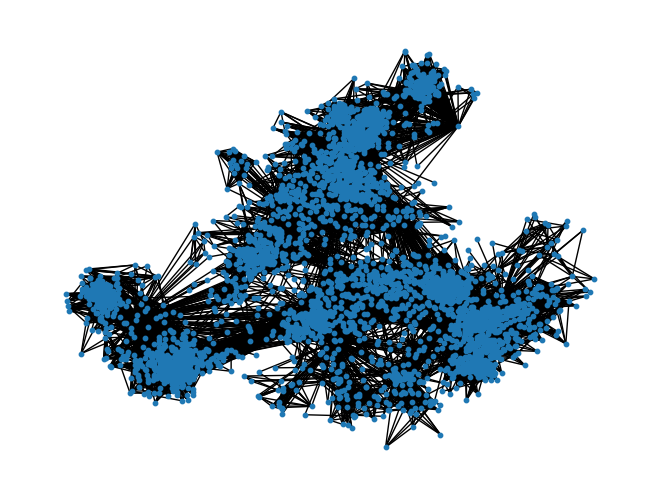

In [ ]:
nx.draw(G, node_size=10)

In [ ]:
import random

def sir_simulation(G, infected_node, beta=0.3, gamma=0.1, steps=50):
    """
    Perform SIR simulation starting from a single node
    Returns total number of infected nodes
    """
    susceptible = set(G.nodes())
    infected = set([infected_node])
    recovered = set()

    susceptible.remove(infected_node)

    for _ in range(steps):
        new_infected = set()
        new_recovered = set()

        for node in infected:
            # Try to infect neighbors
            for neighbor in G.neighbors(node):
                if neighbor in susceptible and random.random() < beta:
                    new_infected.add(neighbor)

            # Recovery
            if random.random() < gamma:
                new_recovered.add(node)

        infected |= new_infected
        infected -= new_recovered
        recovered |= new_recovered
        susceptible -= new_infected

        if len(infected) == 0:
            break

    return len(recovered) + len(infected)

In [ ]:
# Select top nodes from SAASP
top_nodes = df.sort_values("saasp_score", ascending=False)["node"].head(20)

sir_results = []

for node in top_nodes:
    spread = np.mean([sir_simulation(G, str(node)) for _ in range(10)])  # average over runs, convert node to string
    sir_results.append(spread)

sir_df = pd.DataFrame({
    "node": top_nodes,
    "sir_spread": sir_results
})

# Merge with main dataframe
df = df.merge(sir_df, on="node", how="left")

In [ ]:
from scipy.stats import kendalltau, spearmanr

# Rankings
df["rank_saasp"] = df["saasp_score"].rank(ascending=False)
df["rank_pagerank"] = df["pagerank"].rank(ascending=False)
df["rank_degree"] = df["degree"].rank(ascending=False)
df["rank_sir"] = df["sir_spread"].rank(ascending=False)

# Drop NaNs (only nodes with SIR)
eval_df = df.dropna(subset=["sir_spread"])

# Kendall Tau
kt_saasp = kendalltau(eval_df["rank_saasp"], eval_df["rank_sir"])
kt_pagerank = kendalltau(eval_df["rank_pagerank"], eval_df["rank_sir"])
kt_degree = kendalltau(eval_df["rank_degree"], eval_df["rank_sir"])

# Spearman
sp_saasp = spearmanr(eval_df["rank_saasp"], eval_df["rank_sir"])
sp_pagerank = spearmanr(eval_df["rank_pagerank"], eval_df["rank_sir"])
sp_degree = spearmanr(eval_df["rank_degree"], eval_df["rank_sir"])

print("\n=== Ranking Validation ===")
print("Kendall Tau:")
print("SAASP:", kt_saasp)
print("PageRank:", kt_pagerank)
print("Degree:", kt_degree)

print("\nSpearman Correlation:")
print("SAASP:", sp_saasp)
print("PageRank:", sp_pagerank)
print("Degree:", sp_degree)


=== Ranking Validation ===
Kendall Tau:
SAASP: SignificanceResult(statistic=np.float64(-0.23157894736842105), pvalue=np.float64(0.16497640636360544))
PageRank: SignificanceResult(statistic=np.float64(0.010526315789473684), pvalue=np.float64(0.9744669029388741))
Degree: SignificanceResult(statistic=np.float64(0.005305207760646088), pvalue=np.float64(0.9740767980010271))

Spearman Correlation:
SAASP: SignificanceResult(statistic=np.float64(-0.26917293233082706), pvalue=np.float64(0.2511314536907905))
PageRank: SignificanceResult(statistic=np.float64(0.06766917293233082), pvalue=np.float64(0.7768207117441497))
Degree: SignificanceResult(statistic=np.float64(0.06624016265976211), pvalue=np.float64(0.7814229810721611))


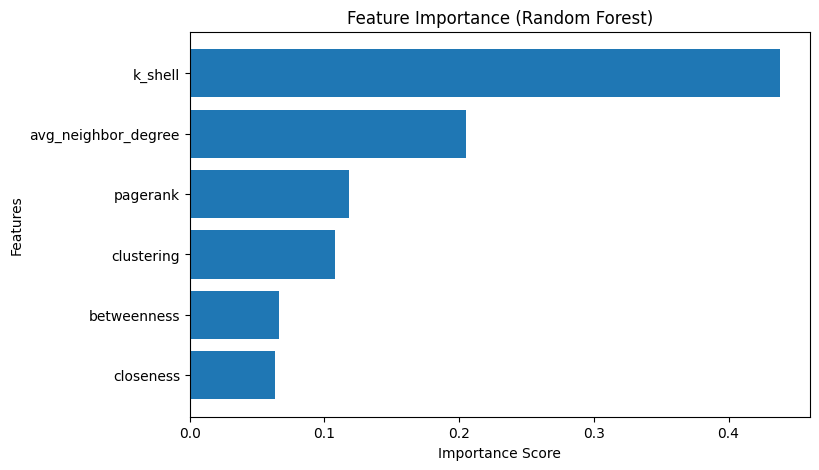

In [ ]:
plt.figure(figsize=(8,5))
plt.barh(feat_imp["feature"], feat_imp["importance"])
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()

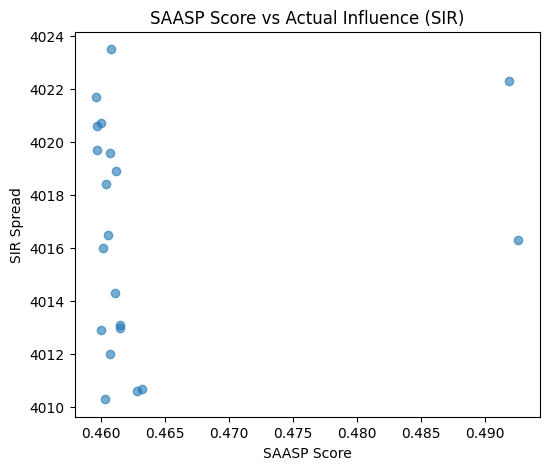

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(eval_df["saasp_score"], eval_df["sir_spread"], alpha=0.6)
plt.title("SAASP Score vs Actual Influence (SIR)")
plt.xlabel("SAASP Score")
plt.ylabel("SIR Spread")
plt.show()

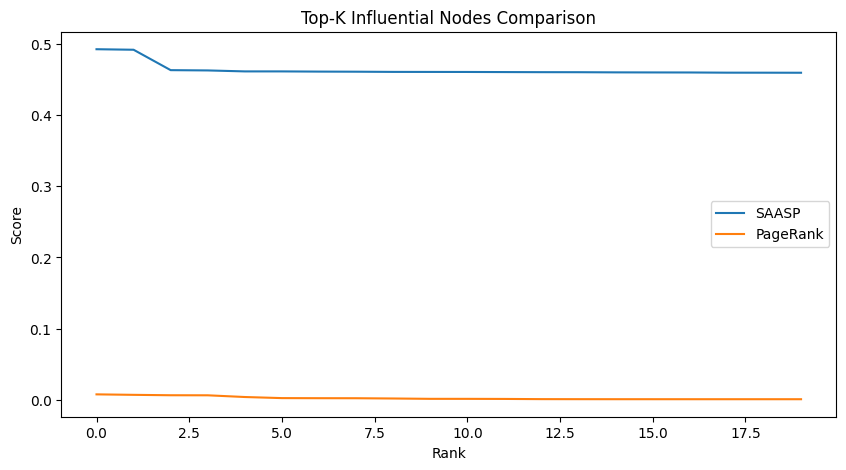

In [ ]:
top_k = 20

top_saasp = df.sort_values("saasp_score", ascending=False).head(top_k)
top_pr = df.sort_values("pagerank", ascending=False).head(top_k)

plt.figure(figsize=(10,5))

plt.plot(top_saasp["saasp_score"].values, label="SAASP")
plt.plot(top_pr["pagerank"].values, label="PageRank")

plt.title("Top-K Influential Nodes Comparison")
plt.xlabel("Rank")
plt.ylabel("Score")
plt.legend()
plt.show()

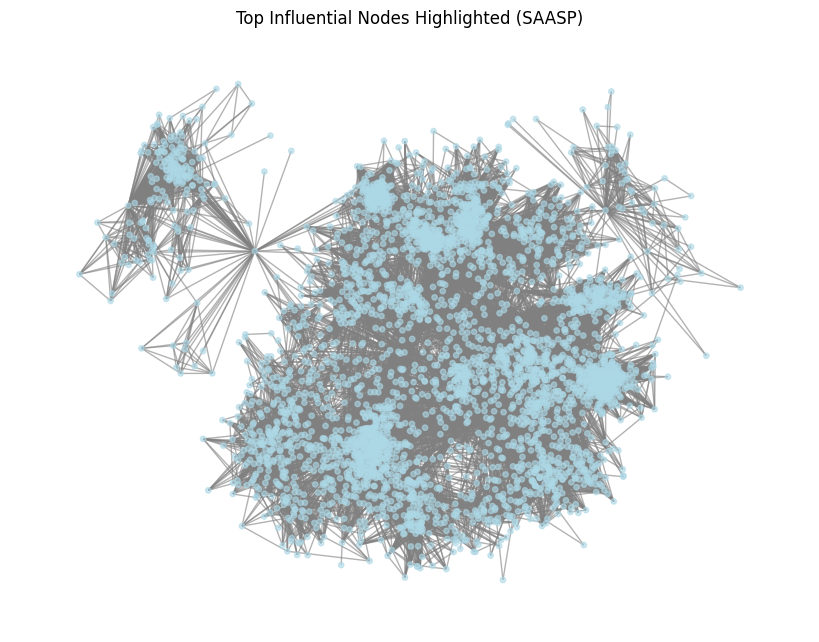

In [ ]:
top_nodes_set = set(df.sort_values("saasp_score", ascending=False)["node"].head(50))

plt.figure(figsize=(8,6))

node_colors = ["red" if node in top_nodes_set else "lightblue" for node in G.nodes()]

nx.draw(G, node_size=15, node_color=node_colors, edge_color="gray", alpha=0.6)

plt.title("Top Influential Nodes Highlighted (SAASP)")
plt.show()